# Air Quality Index (AQI) Analysis of Delhi

## Objective

This project analyzes air pollution patterns in Delhi using hourly pollutant
concentration data. The analysis focuses on particulate matter, gaseous
pollutants, temporal variation, pollutant relationships, statistical patterns,
and potential environmental challenges.

## Dataset

The dataset contains hourly observations of:

- CO
- NO
- NO2
- O3
- SO2
- PM2.5
- PM10
- NH3

The analysis aims to identify major pollution contributors and understand
short-term variations in Delhi's air quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
df = pd.read_csv("delhiaqi.csv")

df.head()

,date,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,2023-01-01 00:00:00,1655.58,1.66,39.41,5.90,17.88,169.29,194.64,5.83
1,2023-01-01 01:00:00,1869.20,6.82,42.16,1.99,22.17,182.84,211.08,7.66
2,2023-01-01 02:00:00,2510.07,27.72,43.87,0.02,30.04,220.25,260.68,11.40
3,2023-01-01 03:00:00,3150.94,55.43,44.55,0.85,35.76,252.90,304.12,13.55
4,2023-01-01 04:00:00,3471.37,68.84,45.24,5.45,39.10,266.36,322.80,14.19


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (561, 9)

Column Names:
['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']

Data Types:
date      object
co       float64
no       float64
no2      float64
o3       float64
so2      float64
pm2_5    float64
pm10     float64
nh3      float64
dtype: object

Missing Values:
date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64


In [4]:
df.describe()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
count,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000,561.000000
mean,3814.942210,51.181979,75.292496,30.141943,64.655936,358.256364,420.988414,26.425062
std,3227.744681,83.904476,42.473791,39.979405,61.073080,227.359117,271.287026,36.563094
min,654.220000,0.000000,13.370000,0.000000,5.250000,60.100000,69.080000,0.630000
25%,1708.980000,3.380000,44.550000,0.070000,28.130000,204.450000,240.900000,8.230000
50%,2590.180000,13.300000,63.750000,11.800000,47.210000,301.170000,340.900000,14.820000
75%,4432.680000,59.010000,97.330000,47.210000,77.250000,416.650000,482.570000,26.350000
max,16876.220000,425.580000,263.210000,164.510000,511.170000,1310.200000,1499.270000,267.510000


In [6]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    561 non-null    datetime64[ns]
 1   co      561 non-null    float64       
 2   no      561 non-null    float64       
 3   no2     561 non-null    float64       
 4   o3      561 non-null    float64       
 5   so2     561 non-null    float64       
 6   pm2_5   561 non-null    float64       
 7   pm10    561 non-null    float64       
 8   nh3     561 non-null    float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 39.6 KB


In [7]:
print("Start Date:", df['date'].min())
print("End Date:", df['date'].max())

Start Date: 2023-01-01 00:00:00
End Date: 2023-01-24 08:00:00


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (561, 9)


In [10]:
missing = df.isnull().sum()

print(missing)

date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64


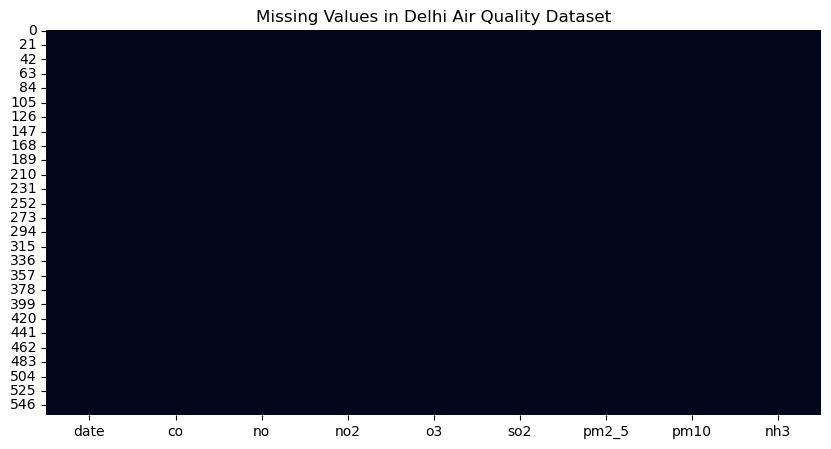

In [11]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values in Delhi Air Quality Dataset")
plt.show()

In [12]:
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['day_name'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month

In [13]:
df[['date', 'hour', 'day', 'day_name', 'month']].head()

,date,hour,day,day_name,month
0,2023-01-01 00:00:00,0,1,Sunday,1
1,2023-01-01 01:00:00,1,1,Sunday,1
2,2023-01-01 02:00:00,2,1,Sunday,1
3,2023-01-01 03:00:00,3,1,Sunday,1
4,2023-01-01 04:00:00,4,1,Sunday,1


In [14]:
pollutants = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']

pollutant_summary = df[pollutants].describe().T

pollutant_summary

,count,mean,std,min,25%,50%,75%,max
co,561.0,3814.942210,3227.744681,654.22,1708.98,2590.18,4432.68,16876.22
no,561.0,51.181979,83.904476,0.00,3.38,13.30,59.01,425.58
no2,561.0,75.292496,42.473791,13.37,44.55,63.75,97.33,263.21
o3,561.0,30.141943,39.979405,0.00,0.07,11.80,47.21,164.51
so2,561.0,64.655936,61.073080,5.25,28.13,47.21,77.25,511.17
pm2_5,561.0,358.256364,227.359117,60.10,204.45,301.17,416.65,1310.20
pm10,561.0,420.988414,271.287026,69.08,240.90,340.90,482.57,1499.27
nh3,561.0,26.425062,36.563094,0.63,8.23,14.82,26.35,267.51


In [15]:
mean_pollutants = df[pollutants].mean().sort_values(ascending=False)

print(mean_pollutants)

co       3814.942210
pm10      420.988414
pm2_5     358.256364
no2        75.292496
so2        64.655936
no         51.181979
o3         30.141943
nh3        26.425062
dtype: float64


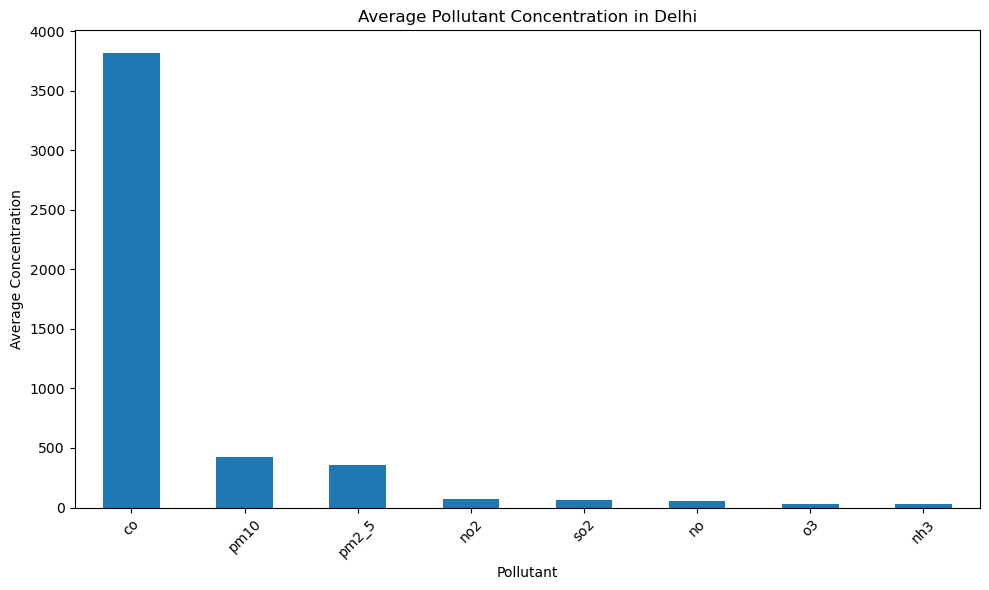

In [16]:
plt.figure(figsize=(10,6))

mean_pollutants.plot(kind='bar')

plt.title("Average Pollutant Concentration in Delhi")
plt.xlabel("Pollutant")
plt.ylabel("Average Concentration")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

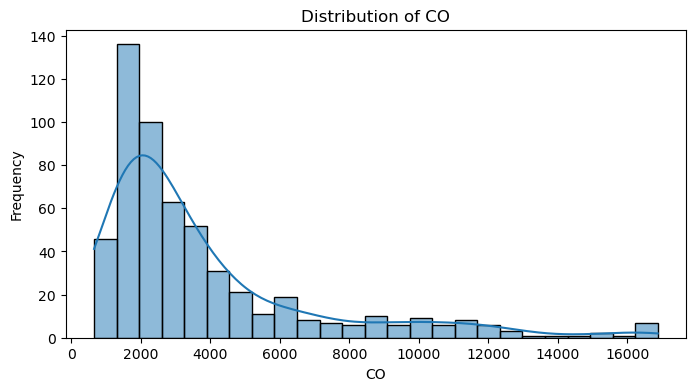

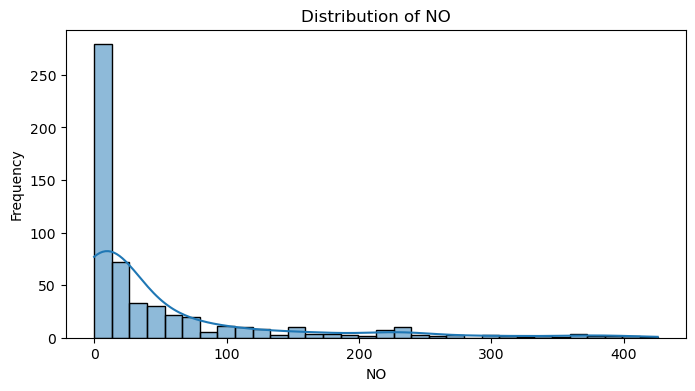

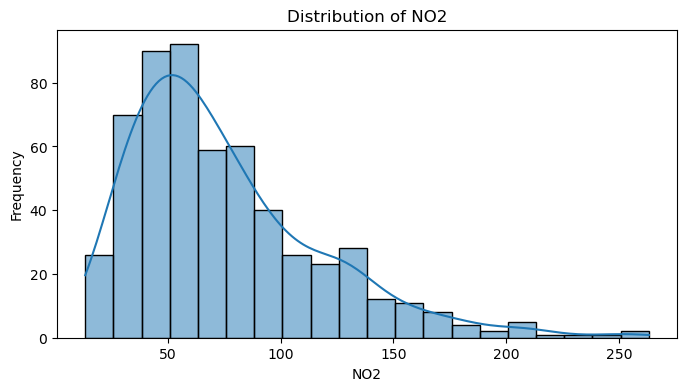

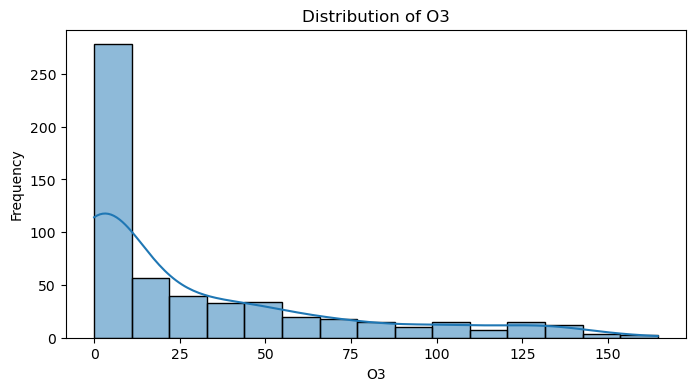

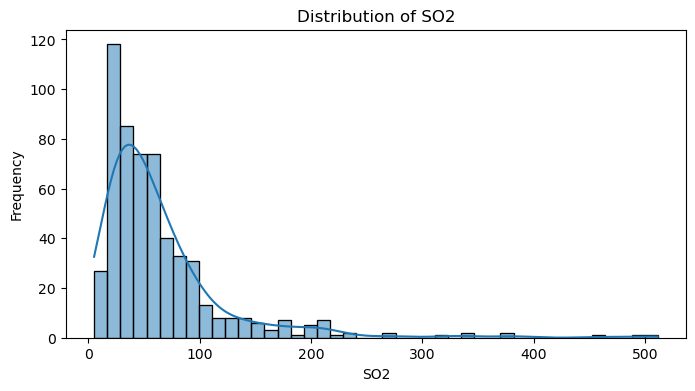

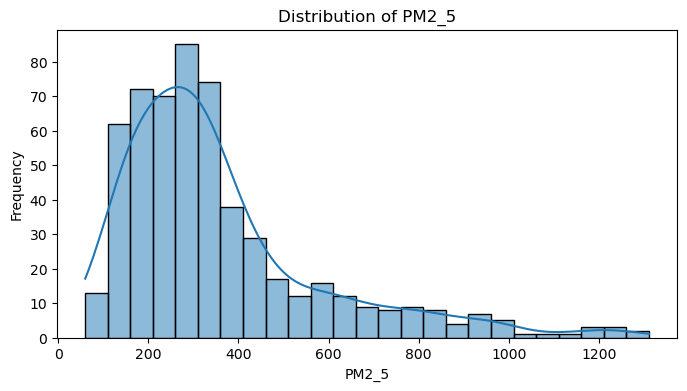

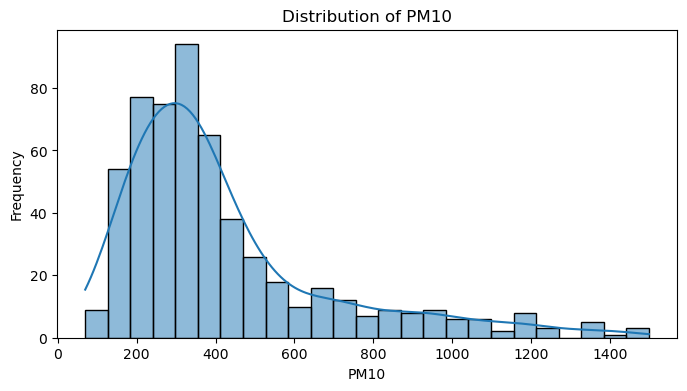

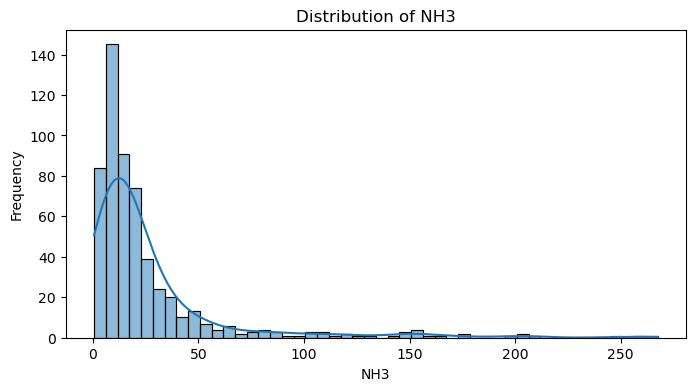

In [17]:
for pollutant in pollutants:
    plt.figure(figsize=(8,4))
    sns.histplot(df[pollutant], kde=True)
    plt.title(f"Distribution of {pollutant.upper()}")
    plt.xlabel(pollutant.upper())
    plt.ylabel("Frequency")
    plt.show()

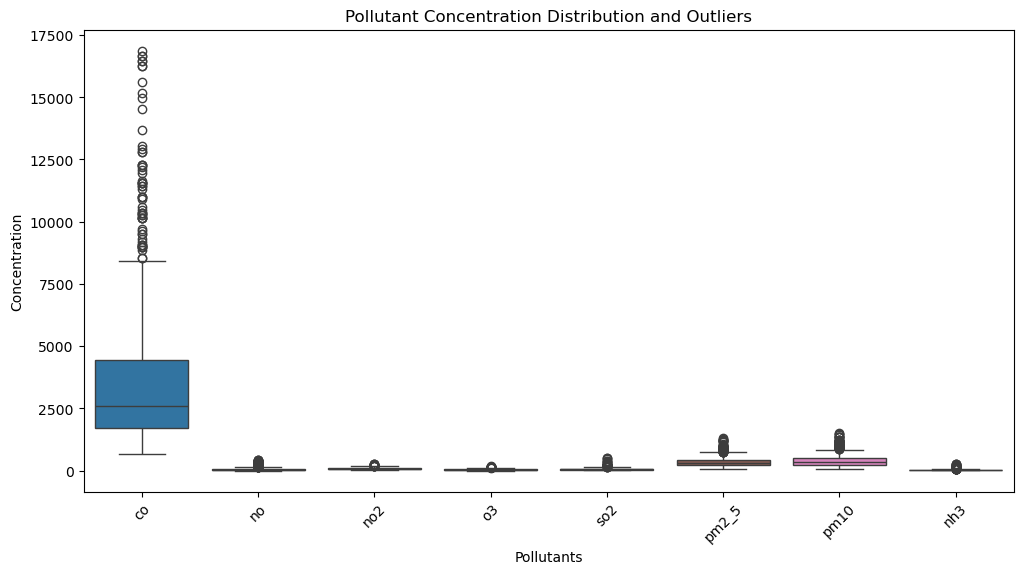

In [18]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[pollutants])

plt.title("Pollutant Concentration Distribution and Outliers")
plt.xlabel("Pollutants")
plt.ylabel("Concentration")
plt.xticks(rotation=45)
plt.show()

In [19]:
outlier_summary = {}

for pollutant in pollutants:
    Q1 = df[pollutant].quantile(0.25)
    Q3 = df[pollutant].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[pollutant] < lower) |
        (df[pollutant] > upper)
    ]
    
    outlier_summary[pollutant] = len(outliers)

outlier_summary

{'co': 61,
 'no': 69,
 'no2': 16,
 'o3': 35,
 'so2': 40,
 'pm2_5': 49,
 'pm10': 54,
 'nh3': 57}

In [20]:
pd.Series(outlier_summary).sort_values(ascending=False)

no       69
co       61
nh3      57
pm10     54
pm2_5    49
so2      40
o3       35
no2      16
dtype: int64

In [21]:
correlation = df[pollutants].corr()

correlation

,co,no,no2,o3,so2,pm2_5,pm10,nh3
co,1.000000,0.969740,0.776402,-0.463082,0.716831,0.953083,0.966801,0.826299
no,0.969740,1.000000,0.702201,-0.377813,0.734503,0.888810,0.903339,0.823638
no2,0.776402,0.702201,1.000000,-0.407177,0.734961,0.698696,0.720050,0.700254
o3,-0.463082,-0.377813,-0.407177,1.000000,-0.049158,-0.450458,-0.468477,-0.299663
so2,0.716831,0.734503,0.734961,-0.049158,1.000000,0.648996,0.658325,0.843635
pm2_5,0.953083,0.888810,0.698696,-0.450458,0.648996,1.000000,0.994088,0.720303
pm10,0.966801,0.903339,0.720050,-0.468477,0.658325,0.994088,1.000000,0.754468
nh3,0.826299,0.823638,0.700254,-0.299663,0.843635,0.720303,0.754468,1.000000


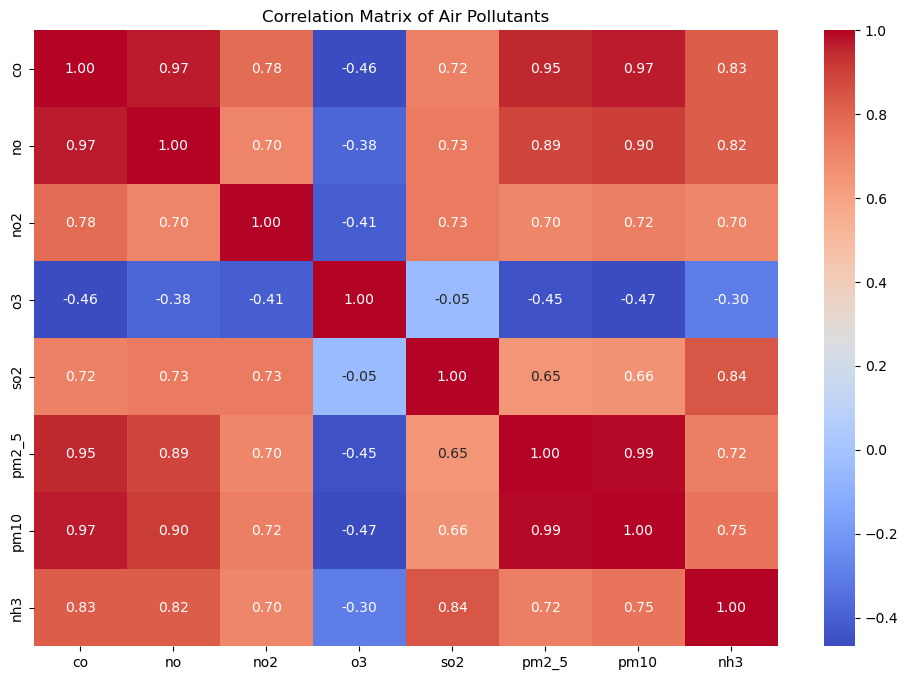

In [22]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Air Pollutants")
plt.show()

In [23]:
hourly_avg = df.groupby('hour')[pollutants].mean()

hourly_avg.head()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
hour,,,,,,,,
0,2207.437917,11.633750,43.068750,19.621667,26.856250,284.571250,314.638750,8.768333
1,2405.484583,15.325417,47.425000,14.841250,31.790000,295.627083,328.781250,11.185000
2,3114.222500,32.671667,56.950000,6.160833,40.123750,336.278750,382.432917,15.395417
3,3719.489167,54.084167,63.304583,3.154583,46.084583,362.630417,416.650000,16.947917
4,3448.565833,49.720833,65.360833,11.333750,54.399167,334.481667,386.673333,17.095000


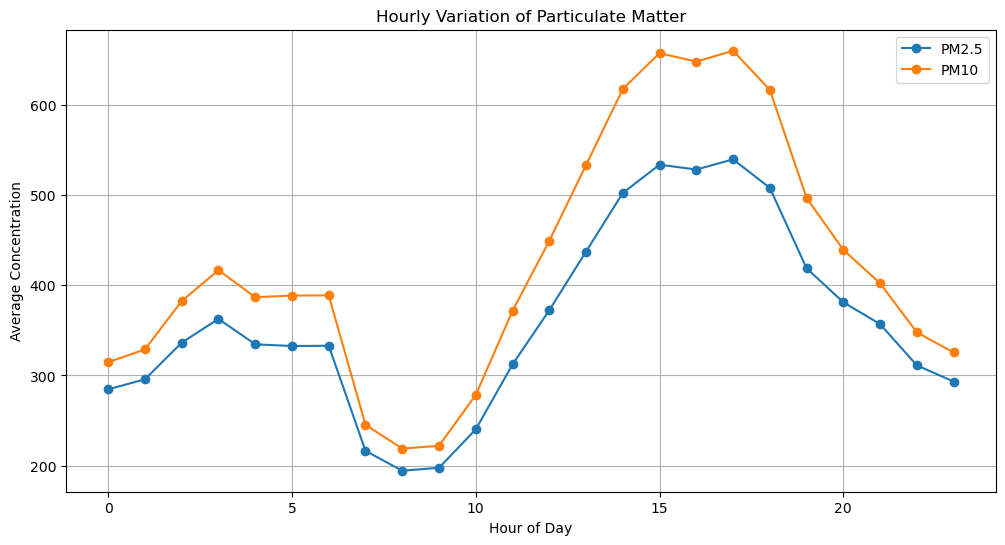

In [24]:
plt.figure(figsize=(12,6))

plt.plot(hourly_avg.index, hourly_avg['pm2_5'], marker='o', label='PM2.5')
plt.plot(hourly_avg.index, hourly_avg['pm10'], marker='o', label='PM10')

plt.title("Hourly Variation of Particulate Matter")
plt.xlabel("Hour of Day")
plt.ylabel("Average Concentration")
plt.legend()
plt.grid(True)

plt.show()

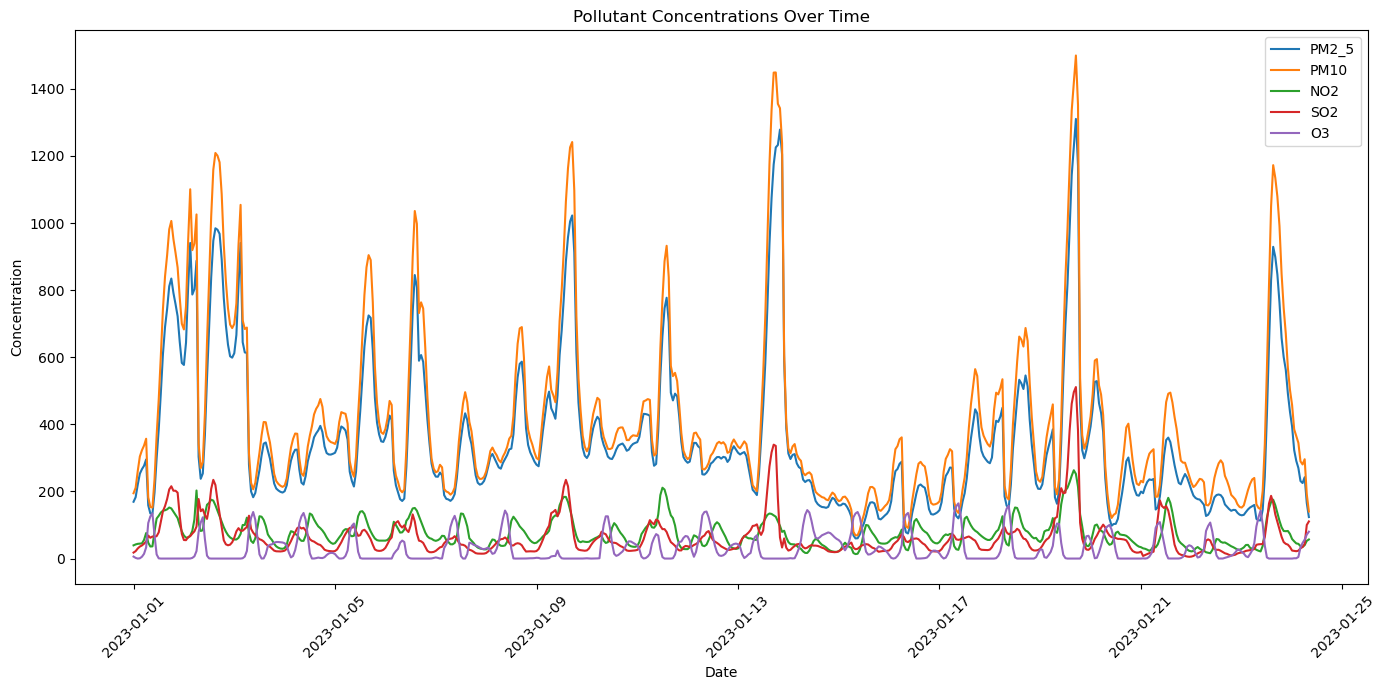

In [25]:
plt.figure(figsize=(14,7))

for pollutant in ['pm2_5', 'pm10', 'no2', 'so2', 'o3']:
    plt.plot(
        df['date'],
        df[pollutant],
        label=pollutant.upper()
    )

plt.title("Pollutant Concentrations Over Time")
plt.xlabel("Date")
plt.ylabel("Concentration")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [26]:
daily_avg = df.groupby(df['date'].dt.date)[pollutants].mean()

daily_avg.head()

,co,no,no2,o3,so2,pm2_5,pm10,nh3
date,,,,,,,,
2023-01-01,5929.152500,112.348750,93.236250,21.290833,102.260417,443.940000,535.040417,63.490833
2023-01-02,7610.322083,140.537500,110.187083,16.977083,110.189583,698.104167,830.148750,49.090000
2023-01-03,3640.492500,39.717500,71.801250,39.477917,59.574583,381.810417,434.333750,18.581667
2023-01-04,2769.867917,8.811667,75.657500,34.640833,52.073750,304.021667,350.490833,13.959583
2023-01-05,4700.819583,62.289583,81.712083,17.712083,58.004583,423.604583,496.787917,21.724583


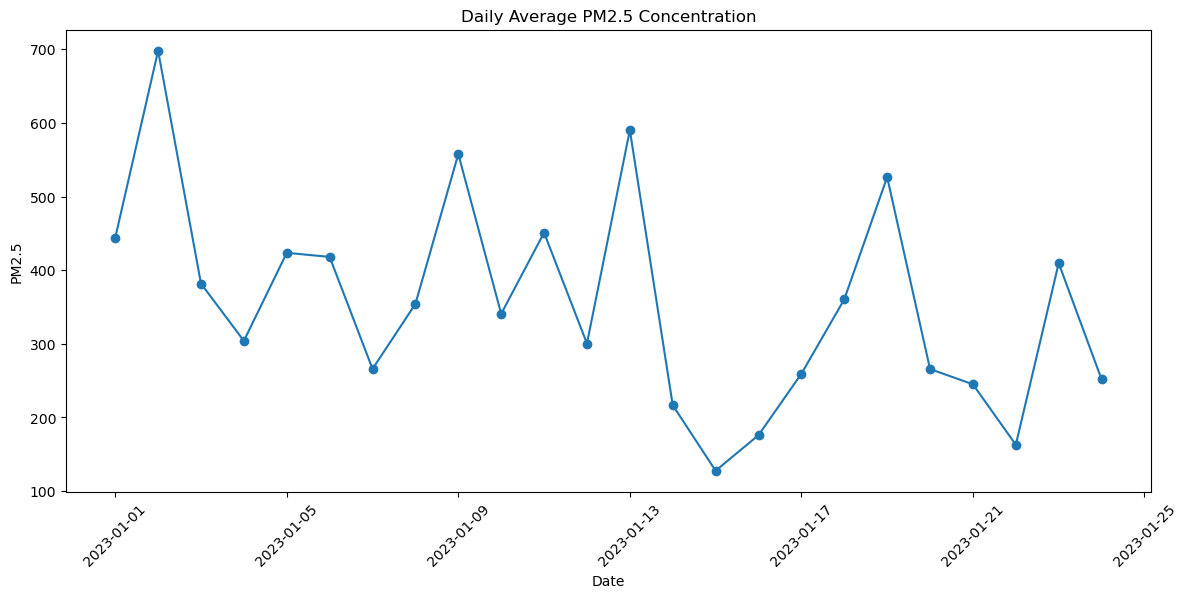

In [27]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_avg.index,
    daily_avg['pm2_5'],
    marker='o'
)

plt.title("Daily Average PM2.5 Concentration")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.xticks(rotation=45)

plt.show()

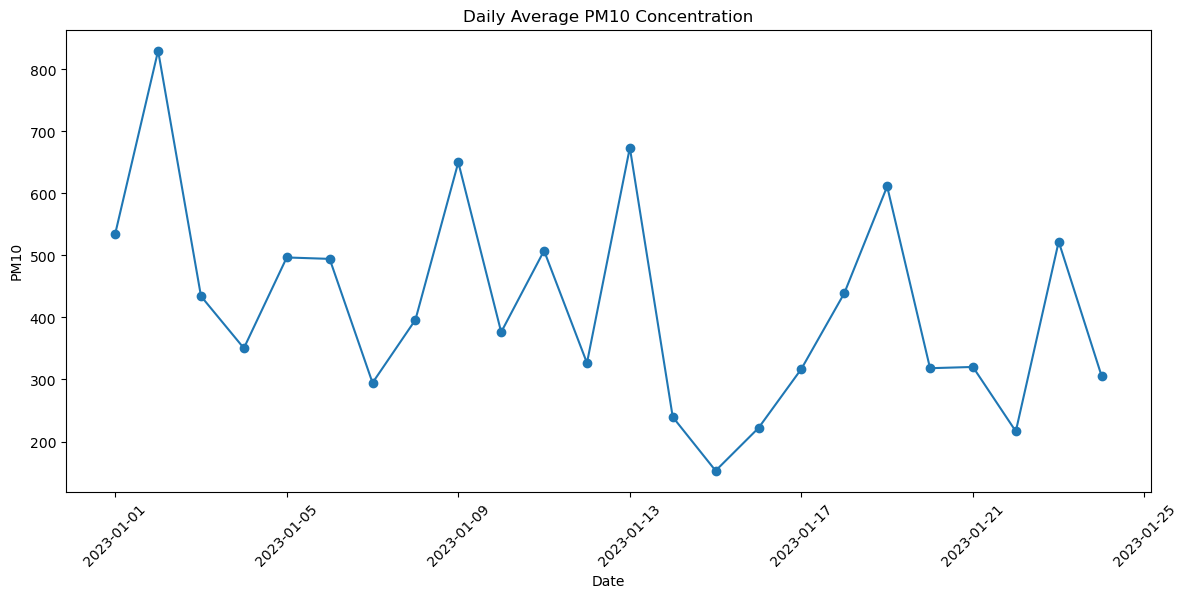

In [28]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_avg.index,
    daily_avg['pm10'],
    marker='o'
)

plt.title("Daily Average PM10 Concentration")
plt.xlabel("Date")
plt.ylabel("PM10")
plt.xticks(rotation=45)

plt.show()

In [29]:
daily_pm = daily_avg.sort_values('pm2_5', ascending=False)

daily_pm[['pm2_5', 'pm10']].head(10)

,pm2_5,pm10
date,,
2023-01-02,698.104167,830.148750
2023-01-13,590.368333,673.778333
2023-01-09,557.806250,650.216667
2023-01-19,526.485833,611.337917
2023-01-11,450.968750,507.721250
2023-01-01,443.940000,535.040417
2023-01-05,423.604583,496.787917
2023-01-06,418.079583,494.499583
2023-01-23,409.547083,522.370417


In [30]:
hourly_pm = df.groupby('hour')[['pm2_5', 'pm10']].mean()

print(hourly_pm.sort_values('pm2_5', ascending=False))

           pm2_5        pm10
hour                        
17    539.517826  659.962174
15    533.620870  657.307826
16    528.229565  647.846522
18    507.915652  616.495217
14    502.223043  617.469130
13    437.294348  533.203043
19    418.675217  496.733043
20    381.065652  439.151739
12    372.226087  449.208261
3     362.630417  416.650000
21    356.821739  402.109130
2     336.278750  382.432917
4     334.481667  386.673333
6     332.872500  388.692083
5     332.568750  388.529583
11    312.113913  371.545217
22    311.110870  347.679130
1     295.627083  328.781250
23    293.195652  325.403478
0     284.571250  314.638750
10    240.183478  278.340870
7     216.307917  245.275417
9     197.552609  221.964783
8     194.313750  218.862083


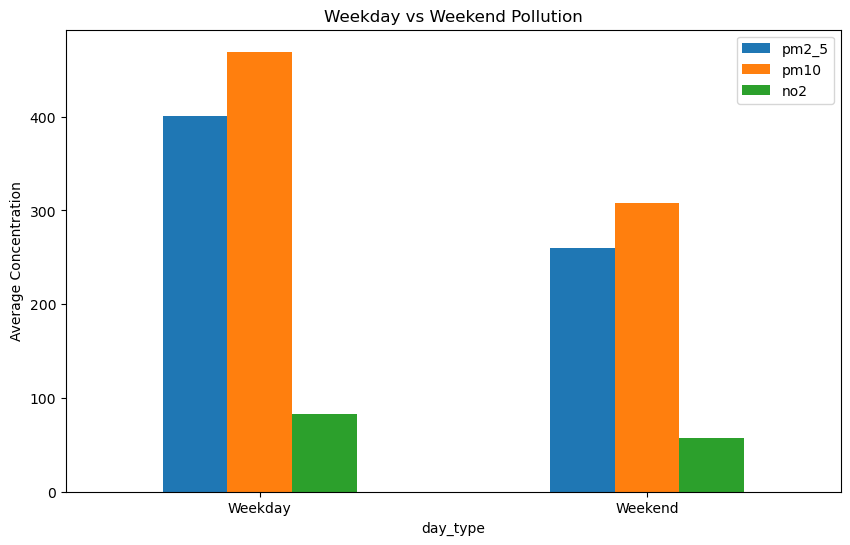

In [31]:
df['day_of_week'] = df['date'].dt.dayofweek

df['is_weekend'] = df['day_of_week'] >= 5

df['day_type'] = np.where(
    df['is_weekend'],
    'Weekend',
    'Weekday'
)
weekday_comparison = df.groupby('day_type')[pollutants].mean()

weekday_comparison
weekday_comparison[['pm2_5', 'pm10', 'no2']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Weekday vs Weekend Pollution")
plt.ylabel("Average Concentration")
plt.xticks(rotation=0)
plt.show()

In [32]:
weekday_pm25 = df[df['day_type'] == 'Weekday']['pm2_5']
weekend_pm25 = df[df['day_type'] == 'Weekend']['pm2_5']

t_stat, p_value = stats.ttest_ind(
    weekday_pm25,
    weekend_pm25,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("The difference is statistically significant at the 5% level.")
else:
    print("The difference is not statistically significant at the 5% level.")

T-statistic: 8.372865965720974
P-value: 6.08523072539748e-16
The difference is statistically significant at the 5% level.


## AQI Considerations

The provided dataset contains pollutant concentrations but does not contain
a pre-calculated AQI value. Therefore, AQI should not be treated as a directly
observed variable.

The analysis focuses on pollutant concentrations and their relationships,
which are the underlying measurements used in air-quality assessment.

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['pollution_score'] = scaler.fit_transform(
    df[['pm2_5', 'pm10']]
).mean(axis=1)

df[['date', 'pm2_5', 'pm10', 'pollution_score']].head()

,date,pm2_5,pm10,pollution_score
0,2023-01-01 00:00:00,169.29,194.64,-0.833486
1,2023-01-01 01:00:00,182.84,211.08,-0.773334
2,2023-01-01 02:00:00,220.25,260.68,-0.599492
3,2023-01-01 03:00:00,252.90,304.12,-0.447491
4,2023-01-01 04:00:00,266.36,322.80,-0.383405


In [34]:
threshold = df['pollution_score'].quantile(0.90)

high_pollution = df[
    df['pollution_score'] >= threshold
]

print("High pollution observations:", len(high_pollution))

high_pollution.head()

High pollution observations: 57


,date,co,no,no2,o3,so2,pm2_5,pm10,nh3,hour,day,day_name,month,day_of_week,is_weekend,day_type,pollution_score
15,2023-01-01 15:00:00,10253.91,228.88,143.95,0.0,156.40,689.94,840.91,110.45,15,1,Sunday,1,6,True,Weekend,1.504712
16,2023-01-01 16:00:00,10574.34,228.88,146.69,0.0,177.38,743.91,904.27,125.65,16,1,Sunday,1,6,True,Weekend,1.740388
17,2023-01-01 17:00:00,11322.02,236.03,152.17,0.0,205.99,811.40,981.17,147.94,17,1,Sunday,1,6,True,Weekend,2.030800
18,2023-01-01 18:00:00,11535.64,236.03,149.43,0.0,215.53,834.55,1006.18,156.04,18,1,Sunday,1,6,True,Weekend,2.127892
19,2023-01-01 19:00:00,10894.78,221.73,139.83,0.0,202.18,791.61,952.00,147.94,19,1,Sunday,1,6,True,Weekend,1.933429


## Geographical Analysis Limitation

The supplied dataset does not contain monitoring-station coordinates,
neighborhood information, district identifiers, or other geographical
variables. Therefore, geographical variation cannot be statistically
evaluated using this dataset.

A future extension could combine air-quality observations with monitoring
station locations, land-use information, traffic density, industrial zones,
and meteorological variables.

## Seasonal Analysis Limitation

The dataset covers only January 2023 and therefore does not contain
sufficient observations across multiple seasons.

Consequently, this study focuses on short-term temporal variation within
the available January period rather than claiming a full seasonal analysis.

A multi-season dataset would be required to compare winter, summer,
monsoon, and post-monsoon pollution patterns.

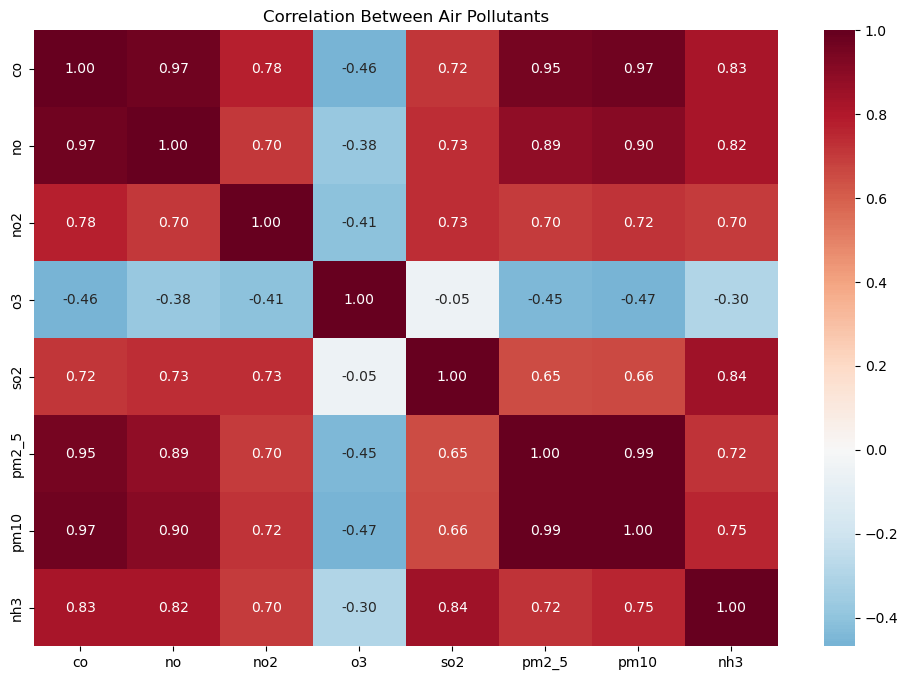

In [35]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df[pollutants].corr(),
    annot=True,
    cmap='RdBu_r',
    center=0,
    fmt='.2f'
)

plt.title("Correlation Between Air Pollutants")
plt.show()

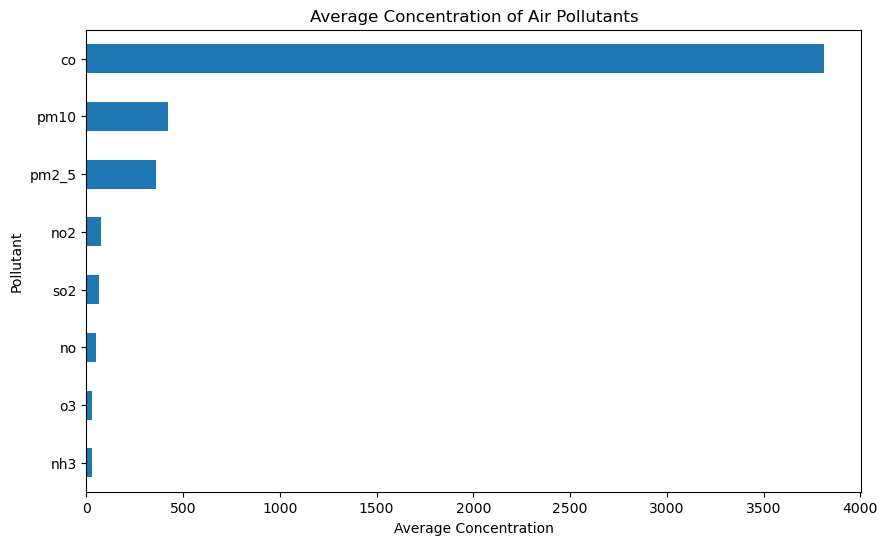

In [36]:
plt.figure(figsize=(10,6))

df[pollutants].mean().sort_values().plot(
    kind='barh'
)

plt.title("Average Concentration of Air Pollutants")
plt.xlabel("Average Concentration")
plt.ylabel("Pollutant")

plt.show()

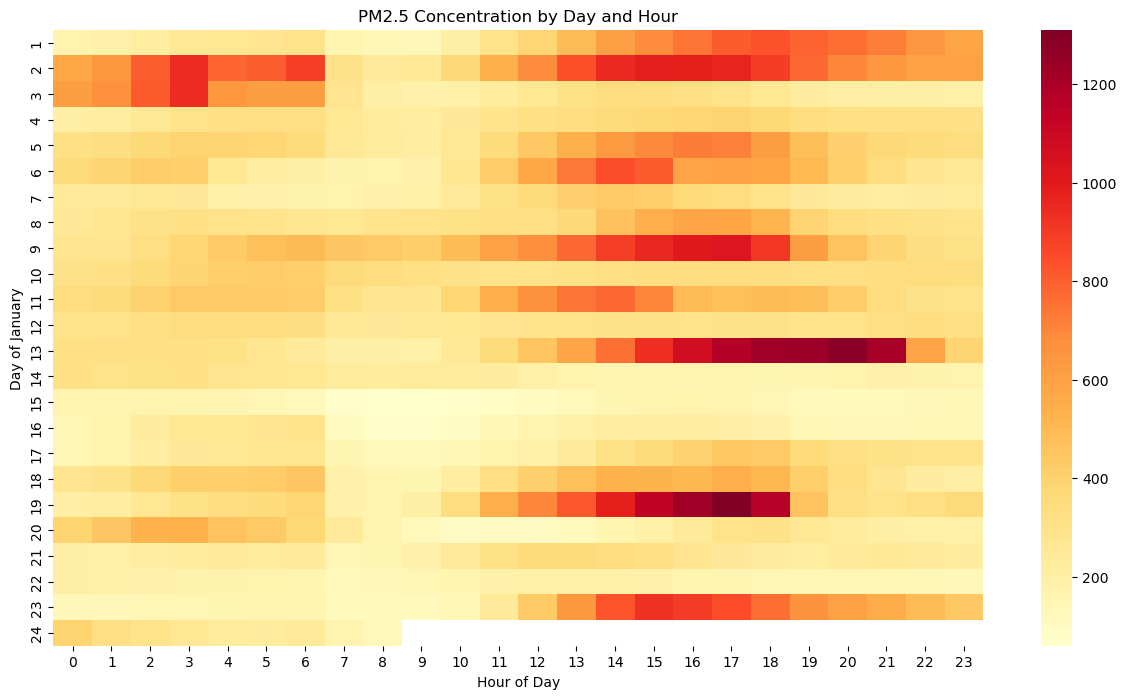

In [37]:
hour_day = df.pivot_table(
    values='pm2_5',
    index='day',
    columns='hour',
    aggfunc='mean'
)

plt.figure(figsize=(15,8))

sns.heatmap(
    hour_day,
    cmap='YlOrRd'
)

plt.title("PM2.5 Concentration by Day and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of January")

plt.show()

In [38]:
skewness = df[pollutants].skew()

print(skewness.sort_values(ascending=False))

nh3      3.484442
so2      3.376733
no       2.345361
co       1.944394
pm2_5    1.681104
pm10     1.673373
o3       1.409605
no2      1.281133
dtype: float64


In [39]:
corr_matrix = df[pollutants].corr()

corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(10)

pm2_5  pm10     0.994088
co     no       0.969740
       pm10     0.966801
       pm2_5    0.953083
no     pm10     0.903339
       pm2_5    0.888810
so2    nh3      0.843635
co     nh3      0.826299
no     nh3      0.823638
co     no2      0.776402
dtype: float64

In [40]:
summary = pd.DataFrame({
    'Mean': df[pollutants].mean(),
    'Median': df[pollutants].median(),
    'Std Dev': df[pollutants].std(),
    'Minimum': df[pollutants].min(),
    'Maximum': df[pollutants].max(),
    'Skewness': df[pollutants].skew()
})

summary

,Mean,Median,Std Dev,Minimum,Maximum,Skewness
co,3814.942210,2590.18,3227.744681,654.22,16876.22,1.944394
no,51.181979,13.30,83.904476,0.00,425.58,2.345361
no2,75.292496,63.75,42.473791,13.37,263.21,1.281133
o3,30.141943,11.80,39.979405,0.00,164.51,1.409605
so2,64.655936,47.21,61.073080,5.25,511.17,3.376733
pm2_5,358.256364,301.17,227.359117,60.10,1310.20,1.681104
pm10,420.988414,340.90,271.287026,69.08,1499.27,1.673373
nh3,26.425062,14.82,36.563094,0.63,267.51,3.484442


# Key Findings

## 1. Pollutant Concentrations

The descriptive analysis shows substantial variation among the measured
pollutants. Particulate matter, particularly PM2.5 and PM10, represents an
important component of the observed pollution levels.

## 2. Temporal Variation

Hourly analysis demonstrates that pollutant concentrations vary throughout
the day. Certain hours show relatively elevated particulate concentrations,
indicating that time-of-day analysis is important for understanding short-term
pollution patterns.

## 3. Pollutant Relationships

Correlation analysis indicates relationships among several pollutants.
Strong correlations suggest that some pollutants may respond to common
emission or atmospheric conditions, although correlation alone does not
establish causation.

## 4. High-Pollution Periods

Daily and hourly analysis identifies periods with relatively elevated
particulate pollution. These periods can be considered potential pollution
episodes for further investigation.

## 5. Statistical Analysis

The weekday-weekend comparison provides a statistical assessment of whether
observed differences in PM2.5 concentrations are likely to represent more
than random variation within the analyzed sample.

## 6. Seasonal and Geographical Limitations

The dataset covers only January 2023 and does not contain geographical
monitoring information. Therefore, full seasonal and geographical comparisons
cannot be established from the supplied data.

# Potential Air Quality Improvement Strategies

Based on the observed pollution patterns, several areas can be considered
for further investigation:

1. Continuous monitoring of PM2.5 and PM10 during high-concentration periods.

2. Investigation of traffic-related pollution during high-pollution hours.

3. Increased monitoring during periods with persistent particulate pollution.

4. Integration of meteorological variables such as wind speed, temperature,
   humidity, and rainfall.

5. Combining air-quality data with geographical information from monitoring
   stations.

6. Developing early-warning systems for short-term pollution episodes.

7. Conducting multi-season analysis to identify recurring seasonal patterns.

# Conclusion

This study analyzed hourly air-quality measurements from Delhi during January
2023. The analysis examined pollutant distributions, temporal patterns,
pollutant correlations, outliers, daily variation, hourly variation, and
weekday-weekend differences.

Particulate pollutants such as PM2.5 and PM10 were given particular attention
because of their substantial observed concentrations in the dataset.
Statistical and visualization-based analysis provided insights into short-term
air-quality variation.

However, the supplied dataset covers only a limited January period and does
not contain geographical information. Therefore, conclusions regarding
seasonal and geographical variation should not be generalized from this
dataset alone.

Future work should incorporate multiple years of data, measurements from
multiple monitoring stations, meteorological variables, traffic information,
and geographical characteristics to develop a more comprehensive model of
Delhi's air-quality dynamics.